# Sentiment Analysis On Movie Reviews
This notebook presents the complete workflow for a sentiment classification project using the IMDb movie review dataset.
The goal is to compare classical machine learning models, Naive Bayes, Logistic Regression, and Support Vector Machine (SVM),with a transformer-based model (BERT) for identifying positive and negative sentiment in text.

# 1. Sentiment Analysis on Movie Reviews
First we have to analyze the sentiment of movie reviews using the Stanford Large Movie Review Dataset.
1. Download and extract the **Stanford Large Movie Review Dataset**.
2. Explore its structure (positive vs. negative reviews).
3. View a few sample reviews.
4. Collect basic statistics (counts, average review length).

In [77]:
# Step 1: Import All necessary Libraries

import os
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.tokenize import word_tokenize
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score
from sklearn.svm import LinearSVC
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Download tokenizer resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /Users/mimi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/mimi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/mimi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/mimi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/mimi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [46]:
# Step 2: Download the IMDb Dataset

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

if not os.path.exists(filename):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, filename)

if not os.path.exists("aclImdb"):
    print("Extracting dataset...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()

print("Dataset ready!")

Dataset ready!


## Step 3: Directory Structure

The dataset should now be extracted into a folder `aclImdb/` with:
- `train/pos` → positive training reviews
- `train/neg` → negative training reviews
- `test/pos` → positive testing reviews
- `test/neg` → negative testing reviews

In [47]:
# Step 3: Check Directories

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

base_dir = os.path.join(current_dir, "aclImdb")

# Define review directories
train_pos_dir = os.path.join(base_dir, "train", "pos")
train_neg_dir = os.path.join(base_dir, "train", "neg")
test_pos_dir = os.path.join(base_dir, "test", "pos")
test_neg_dir = os.path.join(base_dir, "test", "neg")

print("Train positive reviews:", len(os.listdir(train_pos_dir)))
print("Train negative reviews:", len(os.listdir(train_neg_dir)))
print("Test positive reviews:", len(os.listdir(test_pos_dir)))
print("Test negative reviews:", len(os.listdir(test_neg_dir)))

Train positive reviews: 12500
Train negative reviews: 12500
Test positive reviews: 12500
Test negative reviews: 12500


## Step 4: View Sample Reviews

Take one positive and one negative review and display the first 500 characters.

In [48]:
# Step 4: View Sample Reviews

pos_example = open(os.path.join(train_pos_dir, os.listdir(train_pos_dir)[0]), encoding="utf-8").read()
neg_example = open(os.path.join(train_neg_dir, os.listdir(train_neg_dir)[0]), encoding="utf-8").read()

print("Positive Example:\n", pos_example[:500], "\n")
print("Negative Example:\n", neg_example[:500], "\n")

Positive Example:
 For a movie that gets no respect there sure are a lot of memorable quotes listed for this gem. Imagine a movie where Joe Piscopo is actually funny! Maureen Stapleton is a scene stealer. The Moroni character is an absolute scream. Watch for Alan "The Skipper" Hale jr. as a police Sgt. 

Negative Example:
 Working with one of the best Shakespeare sources, this film manages to be creditable to it's source, whilst still appealing to a wider audience.<br /><br />Branagh steals the film from under Fishburne's nose, and there's a talented cast on good form. 



## Step 5: Basic Statistics

Measure:
- Average review length
- Distribution of lengths

Average length (positive reviews): 236.268
Average length (negative reviews): 234.42


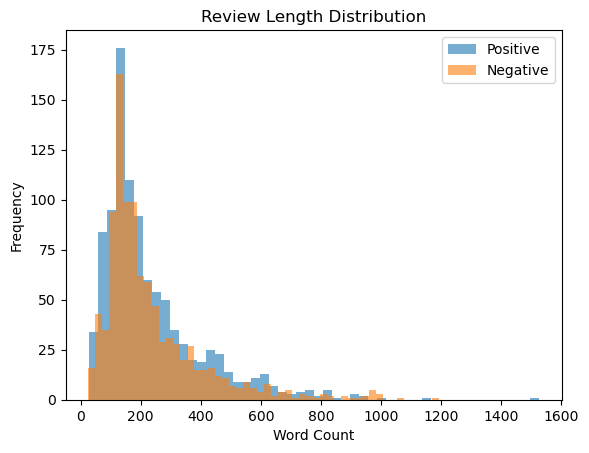

In [49]:
# Step 5: Basic Statistics

lengths_pos = [len(open(os.path.join(train_pos_dir, f), encoding="utf-8").read().split()) 
               for f in os.listdir(train_pos_dir)[:1000]]  # sample 1000 reviews
lengths_neg = [len(open(os.path.join(train_neg_dir, f), encoding="utf-8").read().split()) 
               for f in os.listdir(train_neg_dir)[:1000]]

print("Average length (positive reviews):", np.mean(lengths_pos))
print("Average length (negative reviews):", np.mean(lengths_neg))

# Plot distribution
plt.hist(lengths_pos, bins=50, alpha=0.6, label="Positive")
plt.hist(lengths_neg, bins=50, alpha=0.6, label="Negative")
plt.legend()
plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# 2. Preprocessing Movie Reviews 

Goal is to implement basic text preprocessing:
1. Convert text to **lowercase**.
2. **Remove punctuation** and special characters.
3. **Tokenize** the text (split into words).

In [50]:
# Step 6: Load sample reviews

base_dir = os.path.join("aclImdb")
train_pos_dir = os.path.join(base_dir, "train", "pos")
train_neg_dir = os.path.join(base_dir, "train", "neg")
for path in [train_pos_dir, train_neg_dir]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing directory: {path}")

sample_pos = open(os.path.join(train_pos_dir, os.listdir(train_pos_dir)[0]), encoding="utf-8").read()
sample_neg = open(os.path.join(train_neg_dir, os.listdir(train_neg_dir)[0]), encoding="utf-8").read()
if not os.listdir(train_pos_dir):
    raise FileNotFoundError(f"No files found in {train_pos_dir}")
if not os.listdir(train_neg_dir):
    raise FileNotFoundError(f"No files found in {train_neg_dir}")

print(" Raw Positive Review:\n", sample_pos[:500])
print("\n Raw Negative Review:\n", sample_neg[:500])


 Raw Positive Review:
 For a movie that gets no respect there sure are a lot of memorable quotes listed for this gem. Imagine a movie where Joe Piscopo is actually funny! Maureen Stapleton is a scene stealer. The Moroni character is an absolute scream. Watch for Alan "The Skipper" Hale jr. as a police Sgt.

 Raw Negative Review:
 Working with one of the best Shakespeare sources, this film manages to be creditable to it's source, whilst still appealing to a wider audience.<br /><br />Branagh steals the film from under Fishburne's nose, and there's a talented cast on good form.


## Step 7: Define Preprocessing Functions

Implement:
- `to_lowercase()`
- `remove_punctuation()`
- `tokenize_text()`

In [51]:
# Step 7: Preprocessing Functions

def to_lowercase(text):
    return text.lower()

def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

def tokenize_text(text):
    return word_tokenize(text)

# Combine them into one pipeline
def preprocess(text):
    text = to_lowercase(text)
    text = remove_punctuation(text)
    tokens = tokenize_text(text)
    return tokens

## Step 8: Apply Preprocessing
Let’s see the before and after for positive and negative reviews.

In [52]:
# Step 8: Apply Preprocessing

processed_pos = preprocess(sample_pos)
processed_neg = preprocess(sample_neg)

print(" Preprocessed Positive Review Tokens:\n", processed_pos[:50])
print("\n Preprocessed Negative Review Tokens:\n", processed_neg[:50])

 Preprocessed Positive Review Tokens:
 ['for', 'a', 'movie', 'that', 'gets', 'no', 'respect', 'there', 'sure', 'are', 'a', 'lot', 'of', 'memorable', 'quotes', 'listed', 'for', 'this', 'gem', 'imagine', 'a', 'movie', 'where', 'joe', 'piscopo', 'is', 'actually', 'funny', 'maureen', 'stapleton', 'is', 'a', 'scene', 'stealer', 'the', 'moroni', 'character', 'is', 'an', 'absolute', 'scream', 'watch', 'for', 'alan', 'the', 'skipper', 'hale', 'jr', 'as', 'a']

 Preprocessed Negative Review Tokens:
 ['working', 'with', 'one', 'of', 'the', 'best', 'shakespeare', 'sources', 'this', 'film', 'manages', 'to', 'be', 'creditable', 'to', 'its', 'source', 'whilst', 'still', 'appealing', 'to', 'a', 'wider', 'audiencebr', 'br', 'branagh', 'steals', 'the', 'film', 'from', 'under', 'fishburnes', 'nose', 'and', 'theres', 'a', 'talented', 'cast', 'on', 'good', 'form']


# 3. Preprocessing (Stopwords, Stemming & Lemmatization)


Goal to extend preprocessing by:
1. Removing stopwords
2. Applying stemming
3. Applying lemmatization

In [53]:
# Step 9 : Define preprocessing functions (by using the loaded samples in step 6)

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_with_stopwords(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

def apply_stemming(tokens):
    return [stemmer.stem(t) for t in tokens]

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

In [54]:
# Step 10: Apply preprocessing to positive review

tokens_pos = preprocess_with_stopwords(sample_pos)
tokens_pos_stem = apply_stemming(tokens_pos)
tokens_pos_lemma = apply_lemmatization(tokens_pos)

print(" Tokens (no stopwords):", tokens_pos[:50])
print(" Stemmed tokens:", tokens_pos_stem[:50])
print(" Lemmatized tokens:", tokens_pos_lemma[:50])

 Tokens (no stopwords): ['movie', 'gets', 'respect', 'sure', 'lot', 'memorable', 'quotes', 'listed', 'gem', 'imagine', 'movie', 'joe', 'piscopo', 'actually', 'funny', 'maureen', 'stapleton', 'scene', 'stealer', 'moroni', 'character', 'absolute', 'scream', 'watch', 'alan', 'skipper', 'hale', 'jr', 'police', 'sgt']
 Stemmed tokens: ['movi', 'get', 'respect', 'sure', 'lot', 'memor', 'quot', 'list', 'gem', 'imagin', 'movi', 'joe', 'piscopo', 'actual', 'funni', 'maureen', 'stapleton', 'scene', 'stealer', 'moroni', 'charact', 'absolut', 'scream', 'watch', 'alan', 'skipper', 'hale', 'jr', 'polic', 'sgt']
 Lemmatized tokens: ['movie', 'get', 'respect', 'sure', 'lot', 'memorable', 'quote', 'listed', 'gem', 'imagine', 'movie', 'joe', 'piscopo', 'actually', 'funny', 'maureen', 'stapleton', 'scene', 'stealer', 'moroni', 'character', 'absolute', 'scream', 'watch', 'alan', 'skipper', 'hale', 'jr', 'police', 'sgt']


In [55]:
# Step 11: Apply preprocessing to negative review

tokens_neg = preprocess_with_stopwords(sample_neg)
tokens_neg_stem = apply_stemming(tokens_neg)
tokens_neg_lemma = apply_lemmatization(tokens_neg)

print(" Tokens (no stopwords):", tokens_neg[:50])
print(" Stemmed tokens:", tokens_neg_stem[:50])
print(" Lemmatized tokens:", tokens_neg_lemma[:50])

 Tokens (no stopwords): ['working', 'one', 'best', 'shakespeare', 'sources', 'film', 'manages', 'creditable', 'source', 'whilst', 'still', 'appealing', 'wider', 'audiencebr', 'br', 'branagh', 'steals', 'film', 'fishburnes', 'nose', 'theres', 'talented', 'cast', 'good', 'form']
 Stemmed tokens: ['work', 'one', 'best', 'shakespear', 'sourc', 'film', 'manag', 'credit', 'sourc', 'whilst', 'still', 'appeal', 'wider', 'audiencebr', 'br', 'branagh', 'steal', 'film', 'fishburn', 'nose', 'there', 'talent', 'cast', 'good', 'form']
 Lemmatized tokens: ['working', 'one', 'best', 'shakespeare', 'source', 'film', 'manages', 'creditable', 'source', 'whilst', 'still', 'appealing', 'wider', 'audiencebr', 'br', 'branagh', 'steal', 'film', 'fishburnes', 'nose', 'there', 'talented', 'cast', 'good', 'form']


# 4. Text Encoding

Goal is to:
1. Implement Bag-of-Words (BoW) encoding
2. Implement TF-IDF encoding
3. Compare vocab sizes
4. Visualize word frequencies

In [56]:
# Step 11: Load a subset of data

bbase_dir = os.path.join("aclImdb")
train_pos_dir = os.path.join(base_dir, "train", "pos")
train_neg_dir = os.path.join(base_dir, "train", "neg")
for path in [train_pos_dir, train_neg_dir]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing directory: {path}")


def load_reviews(directory, limit=1000):
    data = []
    for x, filename in enumerate(os.listdir(directory)):
        if x >= limit:
            break
        with open(os.path.join(directory, filename), "r", encoding="utf-8") as f:
            data.append(f.read())
    return data

pos_reviews = load_reviews(train_pos_dir, limit=1000)
neg_reviews = load_reviews(train_neg_dir, limit=1000)

all_reviews = pos_reviews + neg_reviews
labels = [1] * len(pos_reviews) + [0] * len(neg_reviews)

print("Total reviews loaded:", len(all_reviews))

Total reviews loaded: 2000


## Step 12: BoW (Bag-Of Words) Encoding

Convert text into a sparse matric of word counts

In [57]:
# Step 12: BoW

bow_vectorizer = CountVectorizer(max_features=5000, stop_words="english")

X_bow = bow_vectorizer.fit_transform(all_reviews)

print("BOW shape:", X_bow.shape)
print("Vocabulary size (BoW):", len(bow_vectorizer.get_feature_names_out()))

BOW shape: (2000, 5000)
Vocabulary size (BoW): 5000


## Step 13: TF-IDF Encoding

TF-IDF assigns weights based on frequency in document and rarity across documents.

In [59]:
# Step 15: TF-IDF

tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

X_tfidf = tfidf_vectorizer.fit_transform(all_reviews)

print("TF-IDF shape:", X_tfidf.shape)
print("Vocabulary size (TF-IDF):", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF shape: (2000, 5000)
Vocabulary size (TF-IDF): 5000


/var/folders/f0/mws8rny92v90qsncvhfp22g80000gn/T/ipykernel_37123/3040229944.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=bow_freq, palette="Blues_d")


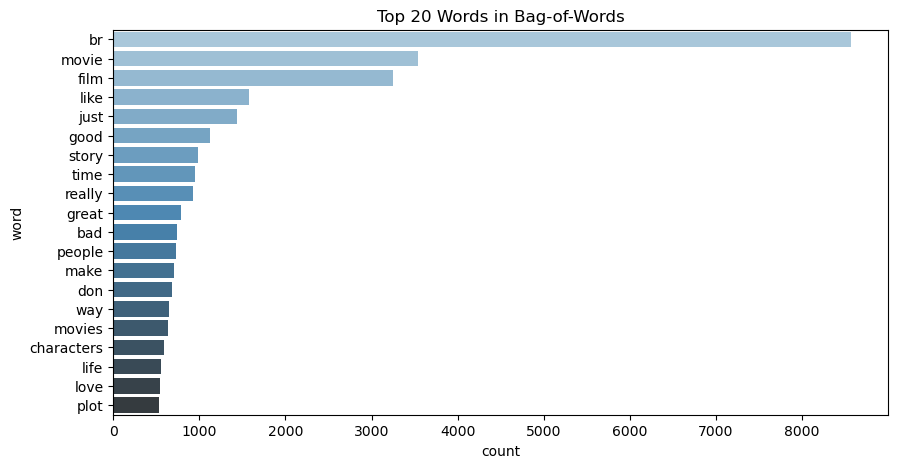

In [60]:
# Step 16, a: Compare Top Words in BoW

word_counts = X_bow.toarray().sum(axis=0)
words = bow_vectorizer.get_feature_names_out()
bow_freq = pd.DataFrame({'word': words, 'count': word_counts})
bow_freq = bow_freq.sort_values(by='count', ascending=False).head(20)

plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=bow_freq, palette="Blues_d")
plt.title("Top 20 Words in Bag-of-Words")
plt.show()

/var/folders/f0/mws8rny92v90qsncvhfp22g80000gn/T/ipykernel_37123/1257588144.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='word', data=tfidf_freq, palette="Greens_d")


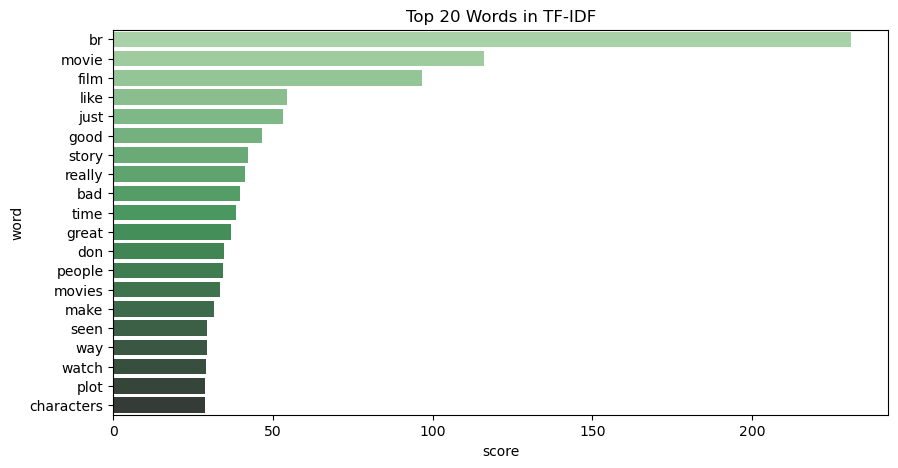

In [61]:
# Step 16, b: Compare Top Words in TF-IDF

tfidf_scores = X_tfidf.toarray().sum(axis=0)
words = tfidf_vectorizer.get_feature_names_out()
tfidf_freq = pd.DataFrame({'word': words, 'score': tfidf_scores})
tfidf_freq = tfidf_freq.sort_values(by='score', ascending=False).head(20)

plt.figure(figsize=(10,5))
sns.barplot(x='score', y='word', data=tfidf_freq, palette="Greens_d")
plt.title("Top 20 Words in TF-IDF")
plt.show()

# 5. Final Pipeline for Text Data

Goal is to:
1. Combine all preprocessing steps into one pipeline
2. Apply it to the IMDb dataset
3. Save cleaned dataset for modeling

In [62]:
# Step 17: Define preprocessing pipeline

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, use_stemming=False):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Tokenization
    # tokens = word_tokenize(text)
    tokens = text.split()  # Simple fallback tokenizer

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming or Lemmatization
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return " ".join(tokens)  # join back into text

In [63]:
# Step 18: reload dataset with printed dataframe (subset for demo, can increase later)

base_dir = os.path.join("aclImdb")
train_pos_dir = os.path.join(base_dir, "train", "pos")
train_neg_dir = os.path.join(base_dir, "train", "neg")
for path in [train_pos_dir, train_neg_dir]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing directory: {path}")

def load_reviews(directory, label, limit=1000):
    data = []
    for i, fname in enumerate(os.listdir(directory)):
        if i >= limit:
            break
        with open(os.path.join(directory, fname), encoding="utf-8") as f:
            data.append((f.read(), label))
    return data

pos_reviews = load_reviews(train_pos_dir, 1, limit=1000)
neg_reviews = load_reviews(train_neg_dir, 0, limit=1000)

all_data = pos_reviews + neg_reviews
df = pd.DataFrame(all_data, columns=["review", "label"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 2)


,review,label
0,For a movie that gets no respect there sure ar...,1
1,Bizarre horror movie filled with famous faces ...,1
2,"A solid, if unremarkable film. Matthau, as Ein...",1
3,It's a strange feeling to sit alone in a theat...,1
4,"You probably all already know this by now, but...",1


In [64]:
# Step 19: Apply preprocessing

df["cleaned_review"] = df["review"].apply(lambda x: preprocess_text(x, use_stemming=False))

df.head(10)

,review,label,cleaned_review
0,For a movie that gets no respect there sure ar...,1,movie get respect sure lot memorable quote lis...
1,Bizarre horror movie filled with famous faces ...,1,bizarre horror movie filled famous face stolen...
2,"A solid, if unremarkable film. Matthau, as Ein...",1,solid unremarkable film matthau einstein wonde...
3,It's a strange feeling to sit alone in a theat...,1,strange feeling sit alone theater occupied par...
4,"You probably all already know this by now, but...",1,probably already know 5 additional episode nev...
5,I saw the movie with two grown children. Altho...,1,saw movie two grown child although clever shre...
6,You're using the IMDb.<br /><br />You've given...,1,youre using imdbbr br youve given hefty vote f...
7,This was a good film with a powerful message o...,1,good film powerful message love redemption lov...
8,"Made after QUARTET was, TRIO continued the qua...",1,made quartet trio continued quality earlier fi...
9,"For a mature man, to admit that he shed a tear...",1,mature man admit shed tear film mature respons...


In [68]:
# Step 20: Save cleaned dataset

data_dir = os.path.join(current_dir, "data")
os.makedirs(data_dir, exist_ok=True)  # Create folder if it doesn't exist

# Save the CSV file there
df.to_csv(os.path.join(data_dir, "cleaned_imdb_reviews.csv"), index=False)
print("Cleaned dataset saved to 'data/cleaned_imdb_reviews.csv'")


Cleaned dataset saved to 'data/cleaned_imdb_reviews.csv'


# After running this, you should have a CSV file with:
- ``review`` (original text)
- ``label`` (0=negative, 1=positive)
- ``cleaned_review`` (fully preprocessed text)

# 6. Baseline Model 1: Naive Bayes with TF-IDF

Train and evaluate a Naive Bayes classifier on IMDb reviews using TF-IDF encoding.

In [78]:
# Step 21: Load pre-processed data
data_path = os.path.join("data", "cleaned_imdb_reviews.csv")

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at: {data_path}")

print("Loading data from:", data_path)
df = pd.read_csv(data_path)

print(df.shape)
df.head()

Loading data from: data/cleaned_imdb_reviews.csv
(2000, 3)


,review,label,cleaned_review
0,For a movie that gets no respect there sure ar...,1,movie get respect sure lot memorable quote lis...
1,Bizarre horror movie filled with famous faces ...,1,bizarre horror movie filled famous face stolen...
2,"A solid, if unremarkable film. Matthau, as Ein...",1,solid unremarkable film matthau einstein wonde...
3,It's a strange feeling to sit alone in a theat...,1,strange feeling sit alone theater occupied par...
4,"You probably all already know this by now, but...",1,probably already know 5 additional episode nev...


In [79]:
# Step 22: Train-test split

X = df["cleaned_review"]
Y = df["label"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 1600 Test size: 400


In [80]:
# Step 23: TF-IDF encoding

tfidif = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidif.fit_transform(X_train)
X_test_tfidf = tfidif.transform(X_test)

print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape:", X_test_tfidf.shape)


TF-IDF Train shape: (1600, 5000)
TF-IDF Test shape: (400, 5000)


In [81]:
# Step 24: Train Naive Bayes model

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, Y_train)

Y_pred = nb_model.predict(X_test_tfidf)

Accuracy: 0.825
Precision: 0.8000
Recall:    0.8643
F1 Score:  0.8309

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.79      0.82       201
           1       0.80      0.86      0.83       199

    accuracy                           0.82       400
   macro avg       0.83      0.83      0.82       400
weighted avg       0.83      0.82      0.82       400



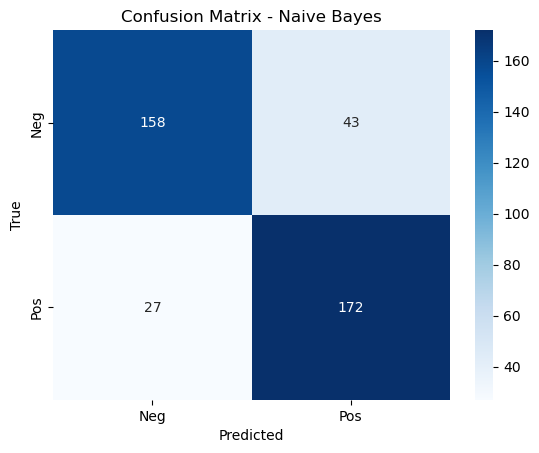

In [82]:
# Step 25: Evaluate the model

acc = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

# Confusion matrix

cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Naive Bayes")
plt.show() 

In [83]:
# Step 26: Collect NB results

def collect_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4)
    }

nb_results = collect_metrics("SVM (TF-IDF)", Y_test, Y_pred)

# 7.Baseline Model 2: Logistic Regression with TF-IDF

To train and evaluate a Logistic Regression classifier on IMDb reviews using TF-IDF features, and compare its performance with Naive Bayes.

In [84]:
# Step 27: Load preprocessed dataset

# Get the absolute path to the data directory
data_path = os.path.join("data", "cleaned_imdb_reviews.csv")

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at: {data_path}")

df = pd.read_csv(data_path)

X = df["cleaned_review"]
Y = df["label"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [85]:
# Step 28: TF-IDF coding
# No need to re-fit the vectorizer every time unless each model is trained separately.

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [86]:
# Step 29: Train Logistic Regression

lr_model = LogisticRegression(max_iter=200, solver="liblinear")  
lr_model.fit(X_train_tfidf, Y_train)

Y_pred = lr_model.predict(X_test_tfidf)

Accuracy: 0.8375
Precision: 0.7965
Recall:    0.9045
F1 Score:  0.8471

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.83       201
           1       0.80      0.90      0.85       199

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



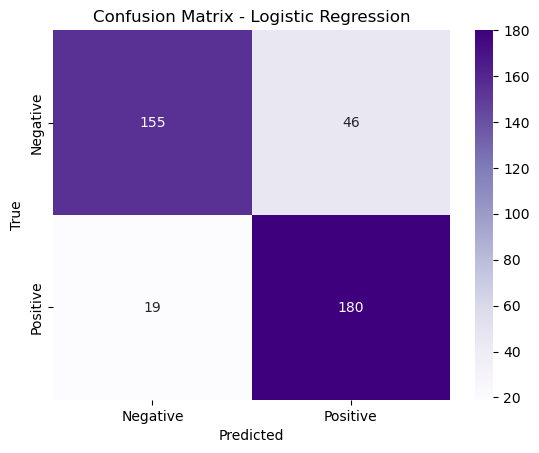

In [87]:
# Step 30: Evaluation
acc = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [88]:
# Step 31: Collect LR results

def collect_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4)
    }

lr_results = collect_metrics("SVM (TF-IDF)", Y_test, Y_pred)


# 8.Baseline Model 3: Support Vector Machine (SVM) with TF-IDF

## Objective
Train a Support Vector Machine classifier using TF-IDF features on the IMDb dataset and compare its performance with Naive Bayes and Logistic Regression.

In [90]:
# Step 32: Load preprocessed dataset

# Get the absolute path to the data directory
data_path = os.path.join("data", "cleaned_imdb_reviews.csv")

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at: {data_path}")

df = pd.read_csv(data_path)

X = df["cleaned_review"]
Y = df["label"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Step 33: TF-IDF coding
# No need to re-fit the vectorizer every time unless each model is trained separately.

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [91]:
# Step 34: Train SVM model

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, Y_train)

Y_pred = svm_model.predict(X_test_tfidf)

Accuracy: 0.815
Precision: 0.7803
Recall:    0.8744
F1 Score:  0.8246

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.76      0.80       201
           1       0.78      0.87      0.82       199

    accuracy                           0.81       400
   macro avg       0.82      0.82      0.81       400
weighted avg       0.82      0.81      0.81       400



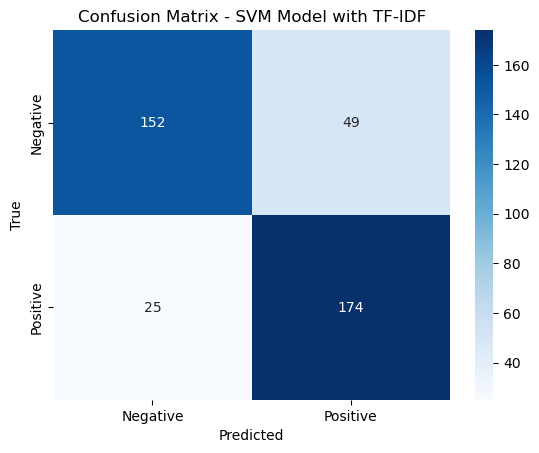

In [92]:
# Step 35: Evaluate the model

acc = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SVM Model with TF-IDF')
plt.show()

In [93]:
# Step 36: Collect SVM results

def collect_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4)
    }

svm_results = collect_metrics("SVM (TF-IDF)", Y_test, Y_pred)

# 9.Baseline Comparison : Naive Bayes vs Logistic Regression vs SVM 

To compare the performance of three baseline models (Naive Bayes, Logistic Regression, SVM) using accuracy, precision, recall, and F1-score.


In [105]:
# Step 37: Collect metrics for Naive Bayes & SVM

results_df = pd.DataFrame([nb_results, lr_results, svm_results])
print(results_df)


                 Model  Accuracy  Precision  Recall      F1
0          Naive Bayes     0.825     0.8000  0.8643  0.8309
1  Logistic Regression     0.835     0.7930  0.9045  0.8451
2         SVM (TF-IDF)     0.815     0.7803  0.8744  0.8246


/var/folders/f0/mws8rny92v90qsncvhfp22g80000gn/T/ipykernel_37123/3177643275.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="viridis")


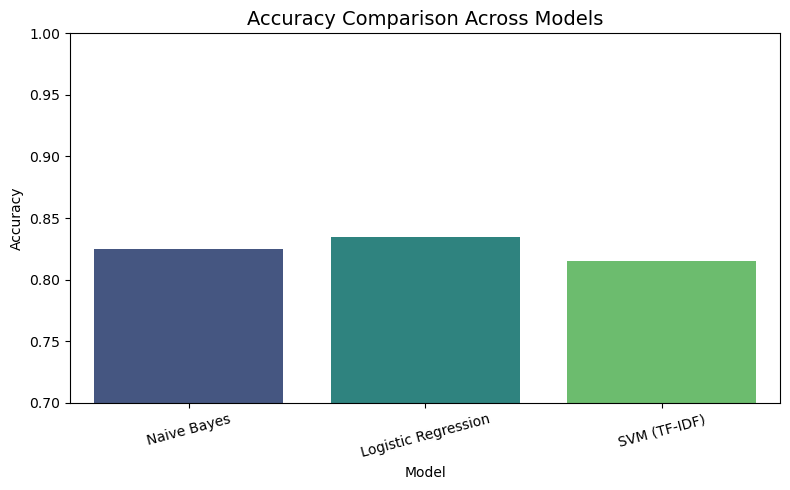

/var/folders/f0/mws8rny92v90qsncvhfp22g80000gn/T/ipykernel_37123/3177643275.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="viridis")


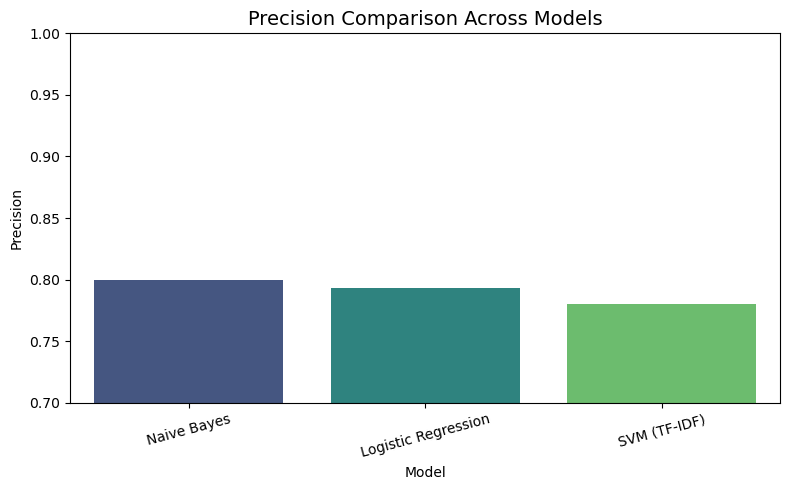

/var/folders/f0/mws8rny92v90qsncvhfp22g80000gn/T/ipykernel_37123/3177643275.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="viridis")


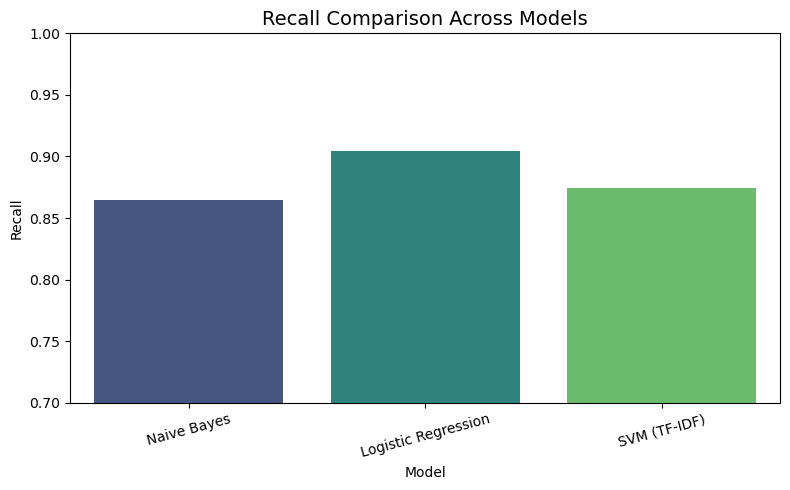

/var/folders/f0/mws8rny92v90qsncvhfp22g80000gn/T/ipykernel_37123/3177643275.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="viridis")


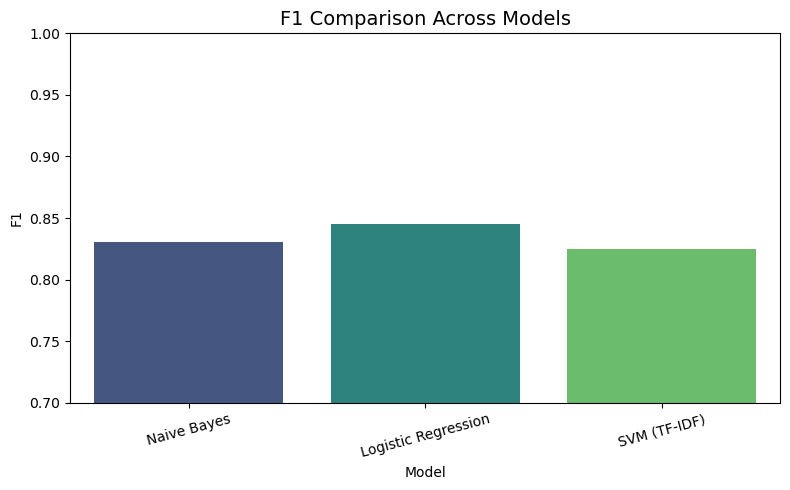

In [103]:
# Step 38: Visualize all the metrics

results_df = pd.DataFrame([nb_results, lr_results, svm_results])

metrics = ["Accuracy", "Precision", "Recall", "F1"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=results_df, x="Model", y=metric, palette="viridis")
    plt.title(f"{metric} Comparison Across Models", fontsize=14)
    plt.ylim(0.7, 1)
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


In [104]:
# Step 39: Save the results

results_df.to_csv("data/baseline_comparison.csv", index=False)
print("Saved: data/baseline_comparison.csv")

Saved: data/baseline_comparison.csv


# Due to computional limitations and capacity, an extended jupter notebook is created starting from the BERT setup